In [2]:
import pandas as pd
from sklearn.cluster import KMeans, AgglomerativeClustering, FeatureAgglomeration
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import tqdm
import os
from pathlib import Path
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import train_test_split

# Preprocessing

In [ ]:
X = pd.read_parquet("../rq1/results/tux_final_outputs/parquet/X_clean.parquet")
y = pd.read_parquet("../rq1/results/tux_final_outputs/parquet/y_clean.parquet")

# Find the ideal number of clusters for kmeans

In [ ]:
inertia = []
K = range(1, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)

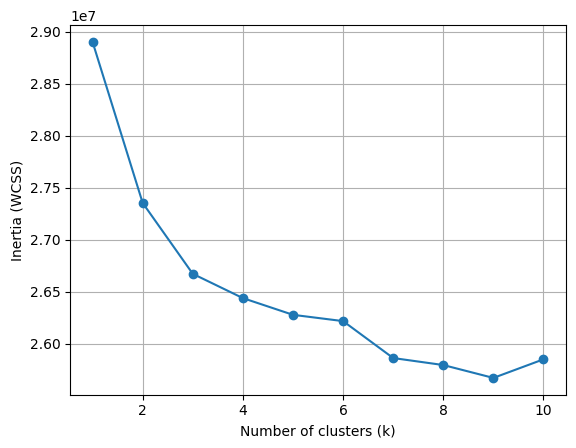

In [ ]:
plt.plot(K, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.grid(True)
plt.savefig("elbow.png",dpi=300)

# Find the ideal numer of Cluesters AgglomerativeClustering

In [ ]:
silhouette_scores = []
K_range = [2]


for k in tqdm.tqdm(K_range):
    model = AgglomerativeClustering(n_clusters=k)
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

print(f"Scores por k: {list(zip(K_range, silhouette_scores))}")

100%|██████████| 1/1 [10:04<00:00, 604.13s/it]

Scores por k: [(6, -0.002136374968123959)]


In [ ]:
calinskiharabasz_score = []
K_range = [2]

for k in K_range:
    model = AgglomerativeClustering(n_clusters=k)
    labels = model.fit_predict(X)
    score = calinski_harabasz_score(X, labels)
    calinskiharabasz_score.append(score)

print(f"Scores por k: {list(zip(K_range, calinskiharabasz_score))}")

Scores por k: [(6, 496.0232874814047)]


In [ ]:
daviesbouldin_score = []
K_range = [2]

for k in K_range:
    model = AgglomerativeClustering(n_clusters=k)
    labels = model.fit_predict(X)
    score = davies_bouldin_score(X, labels)
    daviesbouldin_score.append(score)

print(f"Scores por k: {list(zip(K_range, daviesbouldin_score))}")

Scores por k: [(6, 5.8416274471410405)]


# Kmeand with the elbow distance

In [ ]:
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X)
    print(k, silhouette_score(X, labels))

2 0.06279427716701803
3 0.051659608037269905
4 0.05477838759793024
5 0.04259823592389537
6 0.04636243242458892


In [ ]:
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X)
    print(k, calinski_harabasz_score(X, labels))

2 1240.4204069898033
3 916.0084330138624
4 680.5263378269949
5 546.9916711218584
6 448.69345956627353


In [ ]:
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X)
    print(k, davies_bouldin_score(X, labels))

2 4.165218229084171
3 4.49614964287359
4 5.260599441831333
5 5.808854055329218
6 6.198739781879193


# Cluster after feature selection

In [ ]:
rf_feature = pd.read_csv("../rq1/results/tux_final_outputs/rankings/ranking_rf_all.csv")[:300]
spearman_feature = pd.read_csv("../rq1/results/tux_final_outputs/rankings/ranking_spearman_all.csv")[:300]
xgb_feature = pd.read_csv("../rq1/results/tux_final_outputs/rankings/ranking_xgb_all.csv")[:300]

In [20]:
selected_features_rf = rf_feature["feature"].tolist()
selected_feature_spearman = spearman_feature["feature"].tolist()
selected_feature_xgb = xgb_feature["feature"].tolist()

In [21]:
X_sel_rf = X[selected_features_rf]
X_sel_spearman = X[selected_feature_spearman]
X_sel_xgb = X[selected_feature_xgb]

## Kmeans clusterisation 

In [ ]:
y = pd.read_parquet("../rq1/results/tux_final_outputs/parquet/y_clean.parquet")

In [23]:
k = 2
km = KMeans(n_clusters=k, random_state=42)

clusters_rf = km.fit_predict(X_sel_rf)
clusters_spearman = km.fit_predict(X_sel_spearman)
clusters_xgb = km.fit_predict(X_sel_xgb)



In [24]:
new_df_rf = X_sel_rf.__deepcopy__()
new_df_spearman = X_sel_spearman.__deepcopy__()
new_df_xgb = X_sel_xgb.__deepcopy__()


In [25]:

new_df_rf["cluster"] = clusters_rf
new_df_spearman["cluster"] = clusters_spearman
new_df_xgb["cluster"] = clusters_xgb

new_df_rf = new_df_rf.join(y)
new_df_spearman =new_df_spearman.join(y)
new_df_xgb = new_df_xgb.join(y)

In [26]:
new_df_rf.to_parquet("output/kmeans_rf.parquet")
new_df_spearman.to_parquet("output/kmeans_spearman.parquet")
new_df_xgb.to_parquet("output/kmeans_xgb.parquet")

## AgglomerativeClustering Clusterisation

In [ ]:
y = pd.read_parquet("../rq1/results/tux_final_outputs/parquet/y_clean.parquet")

In [28]:
k = 2
km = AgglomerativeClustering(n_clusters=k)

clusters_rf = km.fit_predict(X_sel_rf)
clusters_spearman = km.fit_predict(X_sel_spearman)
clusters_xgb = km.fit_predict(X_sel_xgb)

In [30]:
new_df_rf = X_sel_rf.__deepcopy__()
new_df_spearman = X_sel_spearman.__deepcopy__()
new_df_xgb = X_sel_xgb.__deepcopy__()

new_df_rf["cluster"] = clusters_rf
new_df_spearman["cluster"] = clusters_spearman
new_df_xgb["cluster"] = clusters_xgb

new_df_rf = new_df_rf.join(y)
new_df_spearman = new_df_spearman.join(y)
new_df_xgb = new_df_xgb.join(y)

new_df_rf.to_parquet("output/Agg_rf.parquet")
new_df_spearman.to_parquet("output/Agg_spearman.parquet")
new_df_xgb.to_parquet("output/Agg_xgb.parquet")

In [31]:
new_df_rf

,DEBUG_INFO,DEBUG_INFO_REDUCED,DEBUG_INFO_SPLIT,RANDOMIZE_BASE,X86_NEED_RELOCS,STRICT_MODULE_RWX,DRM_NOUVEAU,MODULES,DRM_GMA500,DEBUG_INFO_COMPRESSED,...,UIO_CIF,TOUCHSCREEN_MTOUCH,SND_SOC_RT5660,QED_FCOE,MXM_WMI,CAN_VXCAN,ICPLUS_PHY,IPV6_MIP6,cluster,vmlinux
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,11606808.0
1,0,0,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,1,32689448.0
2,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,1,69390160.0
3,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,130817896.0
4,1,0,1,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,1,79820944.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21918,0,0,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,1,27000864.0
21919,0,0,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,1,33746416.0
21920,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,83883840.0
21921,1,0,1,0,0,1,0,1,0,0,...,0,0,0,0,0,0,1,0,0,89409144.0


# Testing XGB, RF

In [ ]:
y = pd.read_parquet("../rq1/results/tux_final_outputs/parquet/y_clean.parquet")

In [ ]:
df = pd.read_csv("../rq1/results/tux_final_outputs/sampling/samples_idx/sample_XGB_k300_diversified_seed42.csv")
sample_indexes = df.iloc[:, 0].values

In [34]:
from sklearn.ensemble import RandomForestRegressor
from pandas import DataFrame

root = Path("/home/pedrol/Documents/new_juliana/output")
for dirpath, dirnames, filenames in os.walk(root):
    dirnames[:] = [d for d in dirnames if not d.startswith(".")]
    for fname in filenames:
        fpath = Path(dirpath) / fname
        print(fname)
        df = pd.read_parquet(fpath)

        df_new: DataFrame = df.iloc[sample_indexes]
        df.drop(index=df_new.index)
        X_train = df_new.drop(columns=['vmlinux'])
        y_train = df_new['vmlinux']
        X_test = df.drop(columns=['vmlinux'])
        y_test = df['vmlinux']

        xgb_model = XGBRegressor()
        xgb_model.fit(X_train, y_train)
        xgb_predictions = xgb_model.predict(X_test)

        rf_model = RandomForestRegressor()
        rf_model.fit(X_train, y_train)
        rf_predictions = rf_model.predict(X_test)

        xgb_mape = mean_absolute_percentage_error(y_test, xgb_predictions)
        xgb_r2 = r2_score(y_test, xgb_predictions)
        rf_mape = mean_absolute_percentage_error(y_test, rf_predictions)
        rf_r2 = r2_score(y_test, rf_predictions)

        print(f"XGB - MAPE: {xgb_mape:.4f}, R2: {xgb_r2:.4f}")
        print(f"RF  - MAPE: {rf_mape:.4f}, R2: {rf_r2:.4f}")


Agg_rf.parquet
XGB - MAPE: 0.1273, R2: 0.8996
RF  - MAPE: 0.2349, R2: 0.8108
Agg_spearman.parquet
XGB - MAPE: 0.3102, R2: 0.7753
RF  - MAPE: 0.3320, R2: 0.7210
Agg_xgb.parquet
XGB - MAPE: 0.1198, R2: 0.9224
RF  - MAPE: 0.2364, R2: 0.8138
kmeans_rf.parquet
XGB - MAPE: 0.1299, R2: 0.8996
RF  - MAPE: 0.2335, R2: 0.8183
kmeans_spearman.parquet
XGB - MAPE: 0.3143, R2: 0.7688
RF  - MAPE: 0.3326, R2: 0.7218
kmeans_xgb.parquet
XGB - MAPE: 0.1203, R2: 0.9258
RF  - MAPE: 0.2338, R2: 0.8123
